# What Guests Actually Care About

A walkthrough of the review-mining analysis in narrative order. The pipeline in
`src/` is the source of truth — this notebook reads what it produced and
explains the reasoning, so it can be read without running anything.

To regenerate everything: `make all` from the repo root (about two minutes).

**The question.** A property manager with finite money to spend on improvements.
Guests leave 84,849 reviews and six numeric subscores. Which experience
attributes actually move the rating and the price a listing can command — and
which are table stakes?

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
FIG = ROOT / "outputs" / "figures"
OUT = ROOT / "outputs"

def metrics(name):
    return json.loads((OUT / f"{name}.json").read_text())

def show(fig):
    display(Image(filename=str(FIG / fig)))

pd.set_option("display.width", 120)


## 1. What survived cleaning

Two exclusions matter. Automated cancellation notices are not guest opinion and have to go. The language screen is a heuristic, so its cost is recomputed on every run rather than assumed away — an earlier version of it discarded over a thousand terse English reviews, which a test caught.

In [2]:
print(json.dumps(metrics("data_summary"), indent=2))
pd.read_csv(OUT / "tables" / "cleaning_log.csv")

{
  "reviews_raw": 84849,
  "reviews_clean": 83168,
  "reviews_removed_share": 0.01981166542917423,
  "reviews_cancellation_notices": 805,
  "reviews_non_english": 839,
  "reviews_short_flagged": 276,
  "reviews_saved_by_rejecting_strict_language_rule": 1367,
  "reviews_mentioning_cancellation_kept": 91,
  "language_screen_suspected_misses": 51,
  "language_screen_suspected_miss_share": 0.0006132166217776068,
  "listings_raw": 3818,
  "listings_clean": 3818,
  "listings_with_rating": 3171,
  "listings_with_any_review": 3169,
  "reviewers": 74436,
  "date_min": "2009-06-07",
  "date_max": "2016-01-03",
  "median_review_chars": 315.0,
  "mean_review_words": 69.20687043093497,
  "median_reviews_per_listing": 12.0,
  "mean_rating": 94.53926206244087,
  "median_rating": 96.0,
  "share_rating_ge_90": 0.8656575212866604,
  "share_rating_ge_95": 0.6379690949227373,
  "rating_p10": 87.0,
  "rating_p25": 93.0,
  "median_price": 100.0,
  "neighbourhood_groups": 17,
  "neighbourhoods": 87
}


,table,step,rows_removed,rows_remaining,rationale
0,listings,raw rows loaded,0,3818,"listings.csv, 92 columns"
1,listings,select analysis columns,0,3818,"33 of 92 columns kept; the rest are URLs, free..."
2,listings,drop non-positive price,0,3818,"a nightly price of zero is a placeholder, not ..."
3,listings,drop missing capacity,0,3818,capacity is needed to build a comparable set
4,listings,flag listings with no rating (kept),0,3818,647 listings have no review_scores_rating (too...
5,listings,final,0,3818,0.0% of raw listing rows removed
6,reviews,raw rows loaded,0,84849,reviews.csv as published by Inside Airbnb
7,reviews,drop empty comment,18,84831,null or whitespace-only comment: a review even...
8,reviews,drop automated cancellation notices,805,84026,platform-generated text ('The host canceled th...
9,reviews,drop reviews with no matching listing,0,84026,review references a listing_id absent from lis...


## 2. The outcome barely moves, and that is the whole problem

The mean Seattle listing scores 94.5 out of 100. Every Airbnb subscore has a median of 10/10. Variation is compressed at the top, so this is not a study of what goes wrong — almost nothing does. It is a study of what separates good from slightly better, and every effect size below has to be read against that ceiling.

mean_rating                      94.53926206244087
median_rating                    96.0
sd_rating                        6.606083179599021
share_rating_ge_90               0.8656575212866604
share_rating_100                 0.24629454430778935
min_subscore_share_perfect_10    0.464903090623363


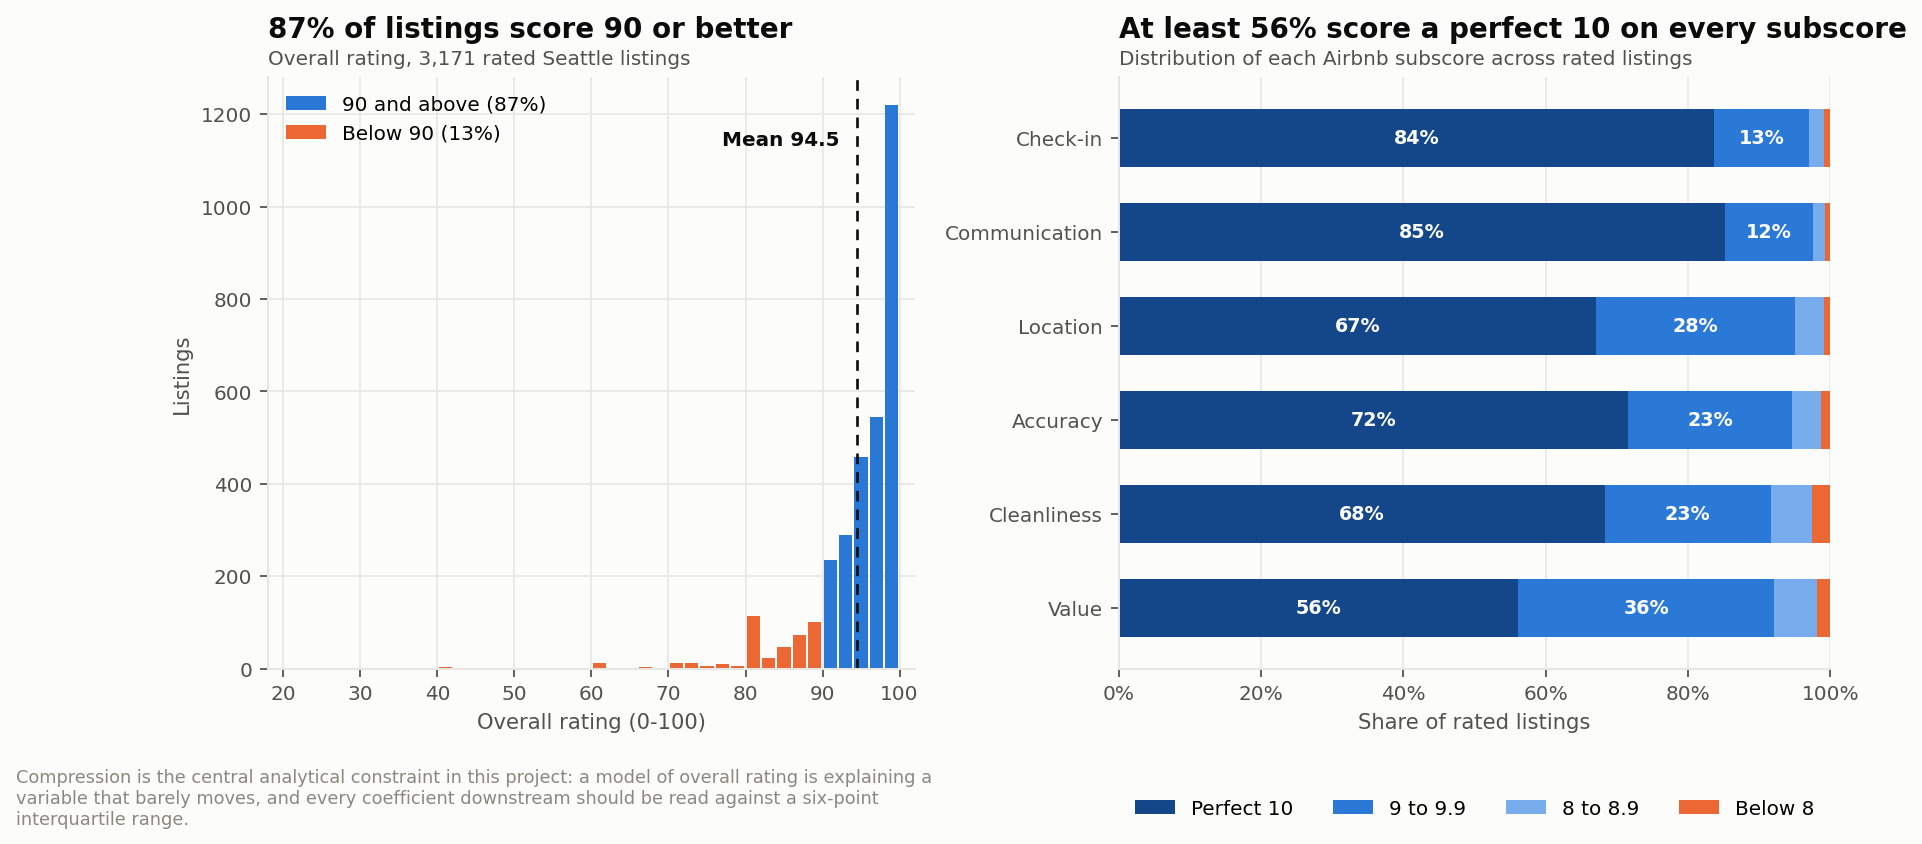

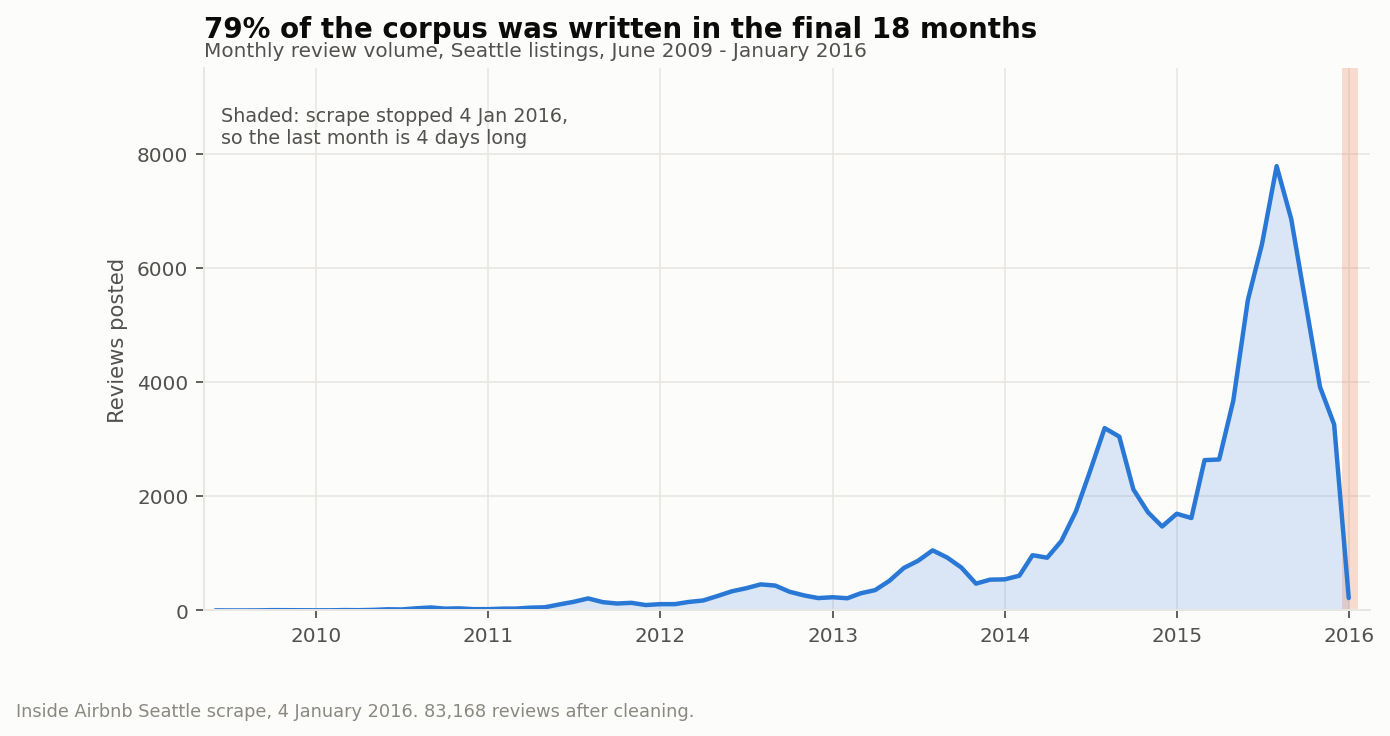

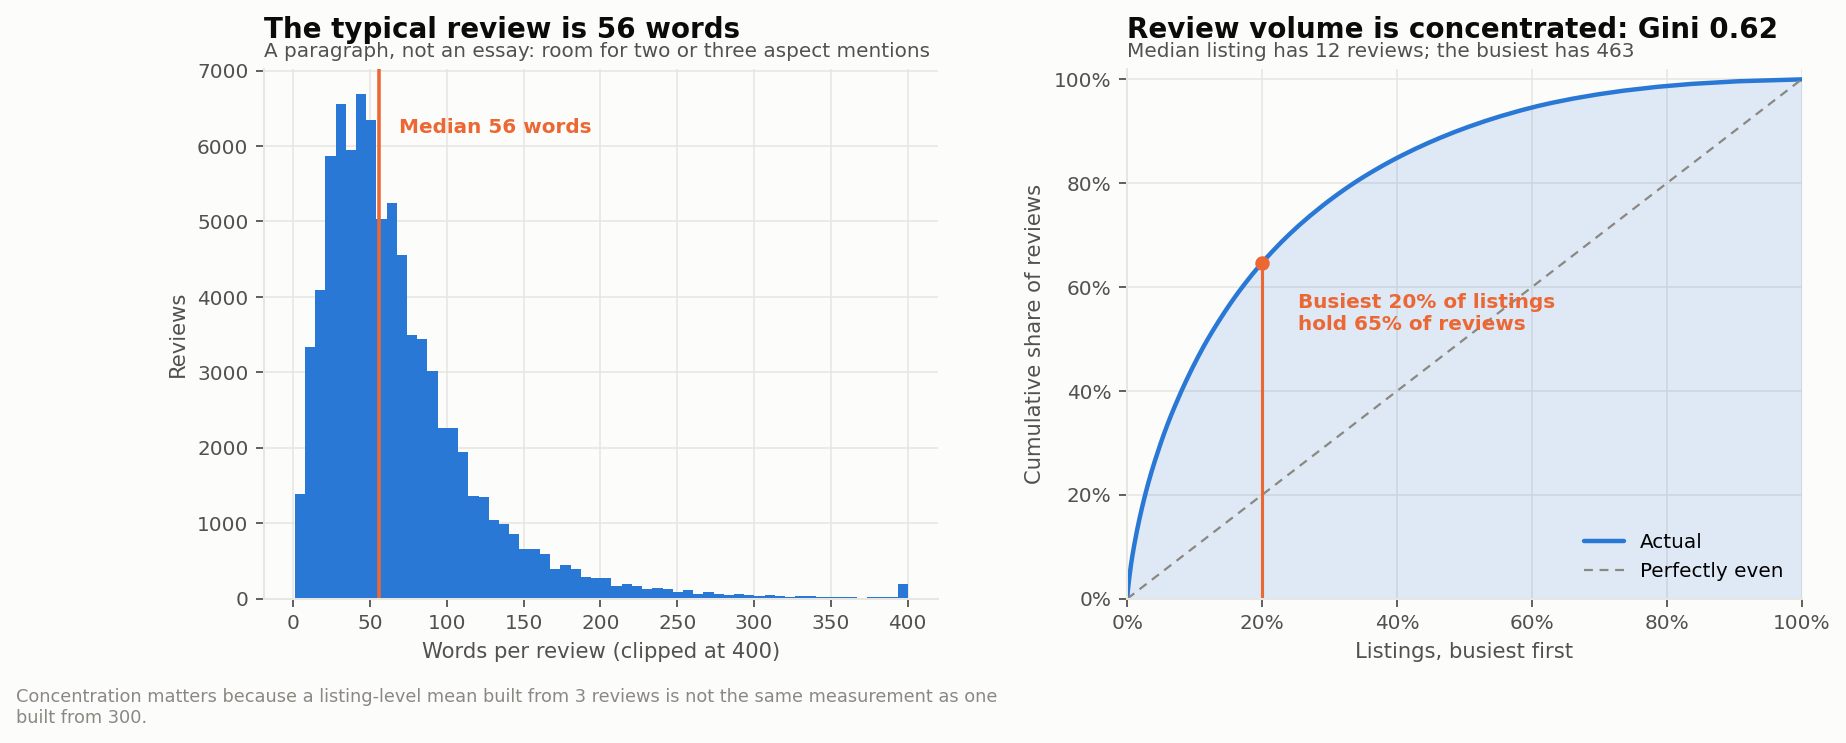

In [3]:
c = metrics("corpus_metrics")
for k in ["mean_rating", "median_rating", "sd_rating", "share_rating_ge_90",
          "share_rating_100", "min_subscore_share_perfect_10"]:
    print(f"{k:32s} {c[k]}")
show("02_rating_compression.png")
show("01_review_volume.png")
show("03_corpus_shape.png")

## 3. Turning text into eight measurable attributes

Eight aspects, matched by a compiled lexicon and scored with VADER on the sentences that mention them. Negative mentions are rare in absolute terms — that is the finding, not a failure of the extractor: guests who had a bad stay mostly do not review at all.

mentions: 265,712 | sentence match rate: 0.634
reviews matching no aspect: 0.0227


,mention rate,negative share,complaints per review
cleanliness,0.3790,0.0143,0.0054
location,0.7847,0.0205,0.0161
host_communication,0.6217,0.0133,0.0083
checkin,0.2430,0.0496,0.0121
value,0.0744,0.0691,0.0051
accuracy,0.1786,0.0350,0.0062
noise,0.2419,0.0617,0.0149
space_comfort,0.6822,0.0198,0.0135


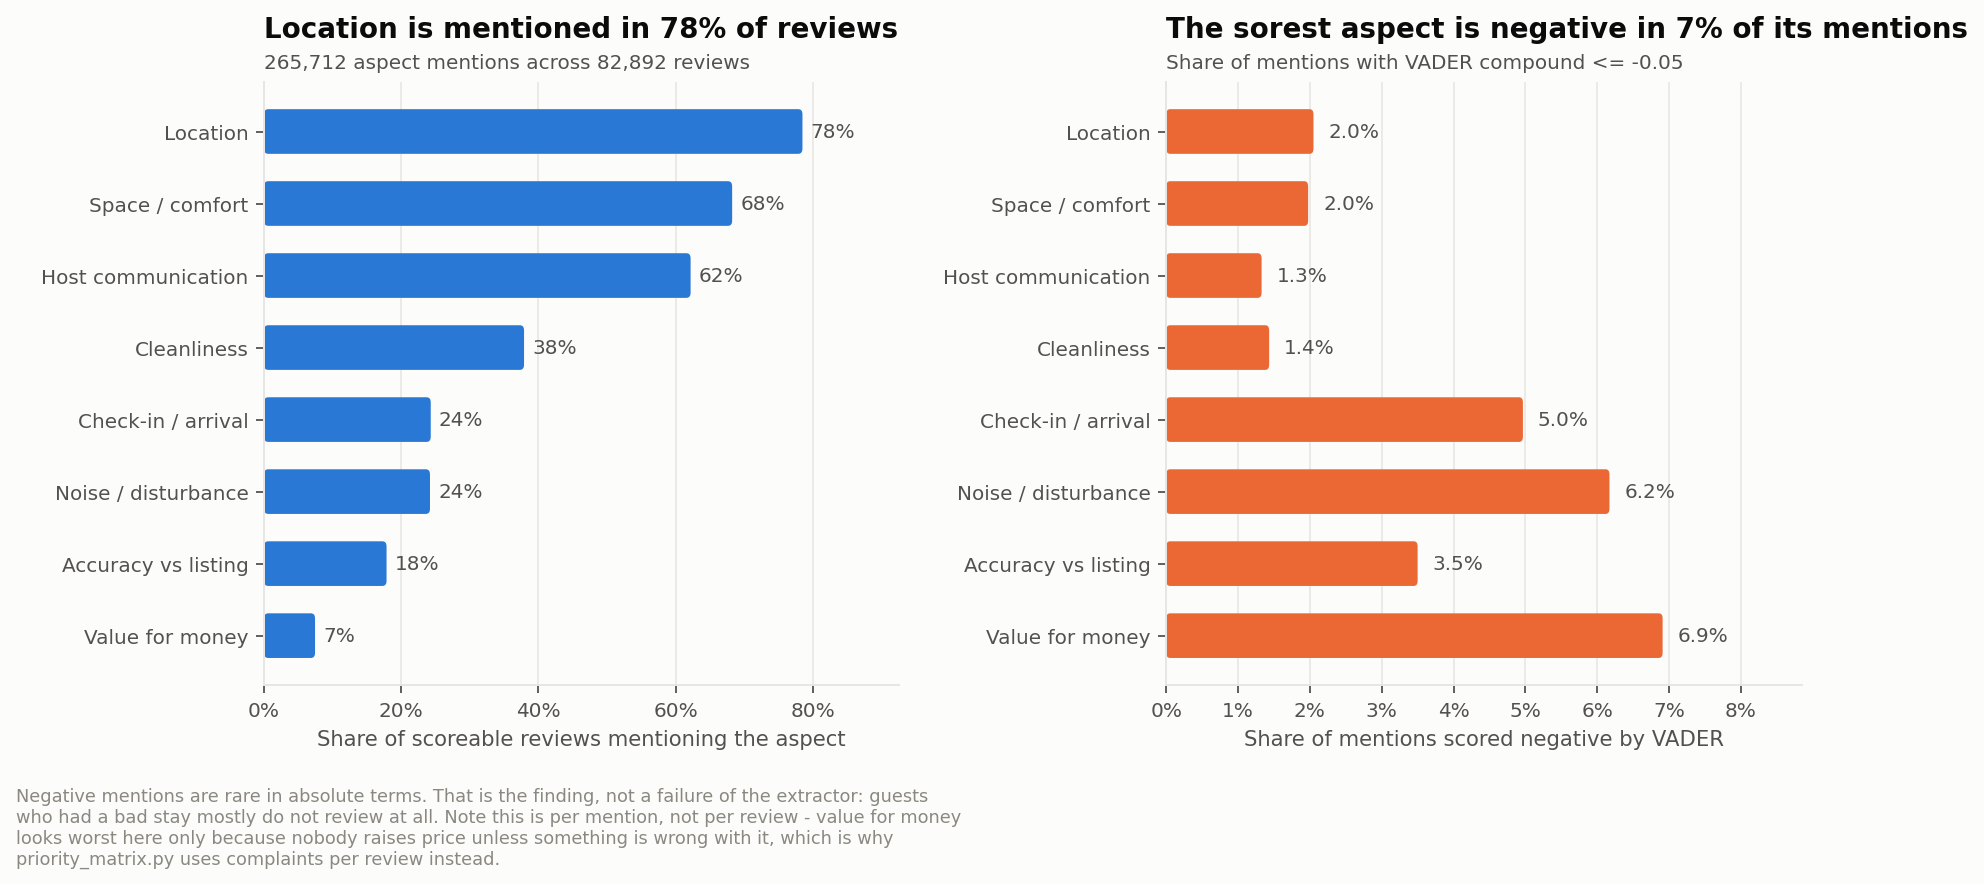

In [4]:
a = metrics("aspect_metrics")
print("mentions:", f'{a["mentions_total"]:,}', "| sentence match rate:", round(a["sentence_match_rate"], 3))
print("reviews matching no aspect:", round(a["reviews_with_no_aspect_share"], 4))
display(pd.DataFrame({"mention rate": a["mention_rate"],
                      "negative share": a["negative_mention_rate"],
                      "complaints per review": a["complaint_incidence"]}).round(4))
show("04_aspect_prevalence.png")

## 4. Does the extraction measure anything real?

The convergent-validity check: correlate the derived aspect sentiment against Airbnb's own subscores where they exist. The answer is **real but weak** — mean r = 0.27, best 0.41 on location. That is reported as-is rather than tuned upward, and it is the honest ceiling on everything that follows.

Note what it cannot check: space/comfort and noise have no Airbnb subscore, so the largest effect in the study rests on an extraction that could not be externally validated.

,aspect,label,subscore,n,pearson_r,spearman_rho,p_value,neg_rate_pearson_r
0,cleanliness,Cleanliness,review_scores_cleanliness,1791,0.403,0.259,0.0,-0.395
1,location,Location,review_scores_location,1828,0.408,0.394,0.0,-0.184
2,host_communication,Host communication,review_scores_communication,1826,0.244,0.222,0.0,-0.188
3,checkin,Check-in / arrival,review_scores_checkin,1690,0.173,0.160,0.0,-0.178
4,value,Value for money,review_scores_value,1013,0.174,0.171,0.0,-0.097
5,accuracy,Accuracy vs listing,review_scores_accuracy,1600,0.192,0.188,0.0,-0.180
6,noise,Noise / disturbance,NaN,0,NaN,NaN,NaN,NaN
7,space_comfort,Space / comfort,NaN,0,NaN,NaN,NaN,NaN


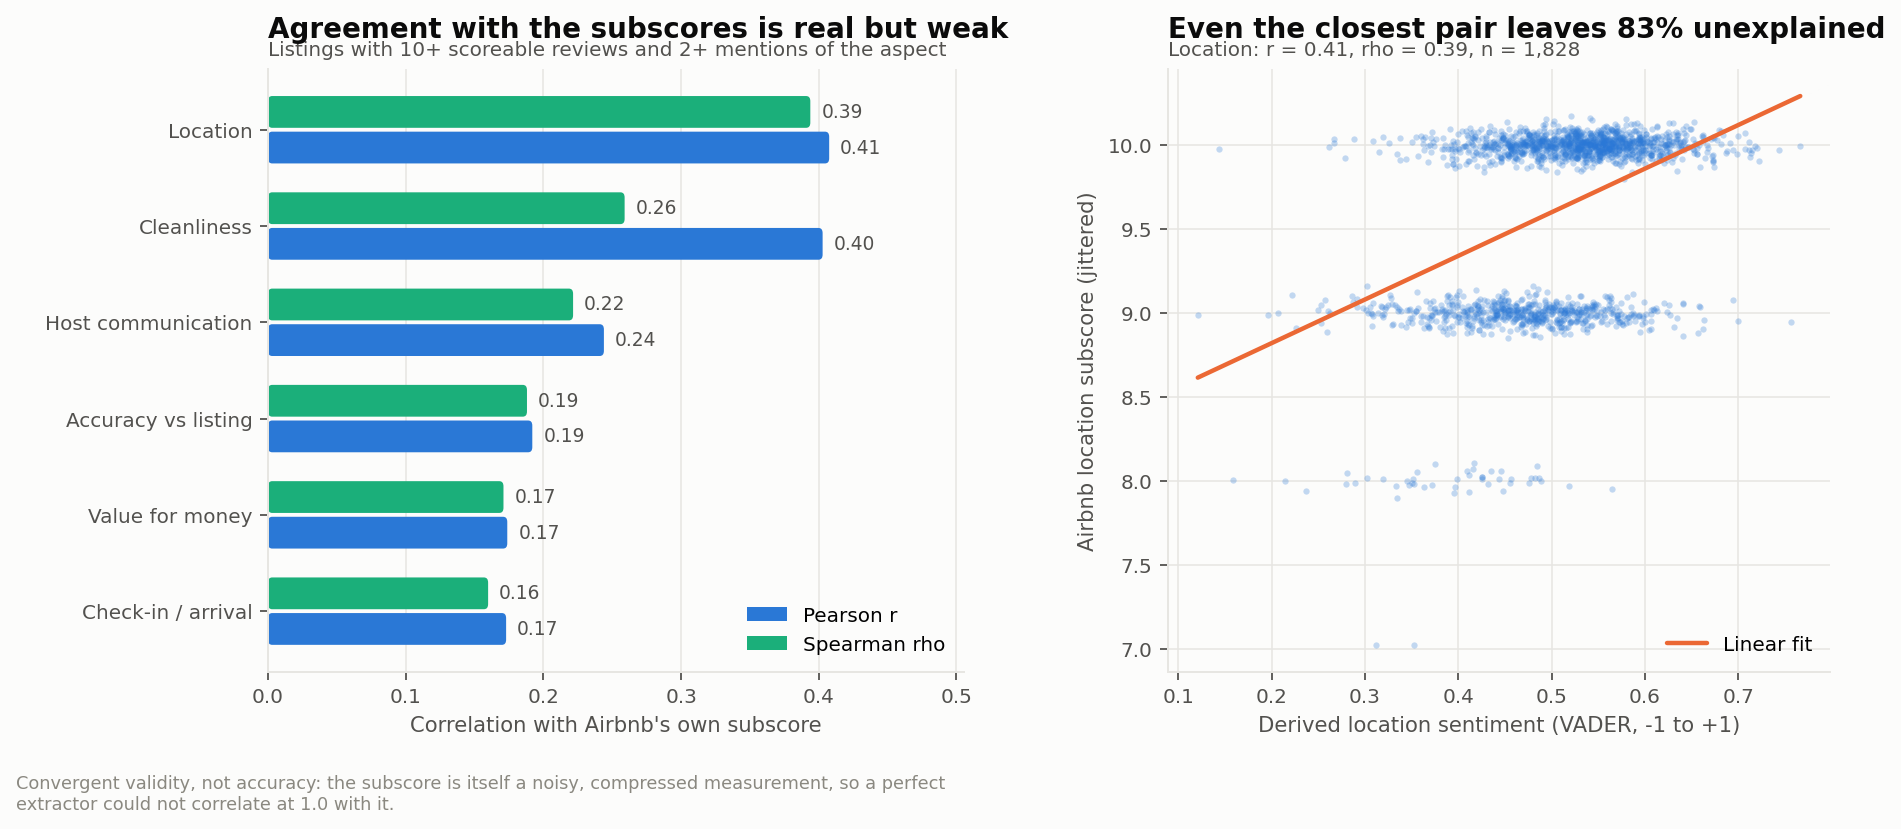

In [5]:
display(pd.read_csv(OUT / "tables" / "aspect_validation.csv").round(3))
show("05_aspect_validation.png")

## 5. Which attributes actually move the rating

Controlling for room type, size, area, price, review count and host tenure. Aspect sentiment lifts held-out R² from 0.09 to 0.40 — so the text carries real signal the structured fields do not.

These are **associations**. The confound that cannot be ruled out: better hosts run better properties *and* write better listings, so an aspect coefficient partly measures host quality rather than the attribute.

rating        - controls only: 0.085 | with aspects: 0.396
price premium - controls only: 0.01 | with aspects: 0.042


,coef,ci_lo,ci_hi,significant,ols_coef,ols_p,gbm_gain_share
sent_space_comfort,0.924075,0.695644,1.108095,True,0.927046,0.0,0.349101
sent_cleanliness,0.679742,0.45898,0.945324,True,0.779058,0.0,0.144225
log_price,0.568194,0.371266,0.7647,True,0.947502,0.0,0.033993
talk_value,-0.563872,-0.76889,-0.374658,True,-0.624154,0.0,0.08424
n_amenities,0.451967,0.298022,0.598217,True,0.440146,0.0,0.029758
sent_host_communication,0.403194,0.226232,0.578459,True,0.421401,0.000042,0.071062
talk_host_communication,0.381811,0.209998,0.548327,True,0.359487,0.000069,0.029528
talk_space_comfort,0.371567,0.204378,0.557771,True,0.460908,0.0,0.025551
talk_noise,-0.318093,-0.541576,-0.131237,True,-0.358321,0.000235,0.032865
sent_location,0.27553,0.064595,0.455231,True,0.199096,0.049389,0.026072


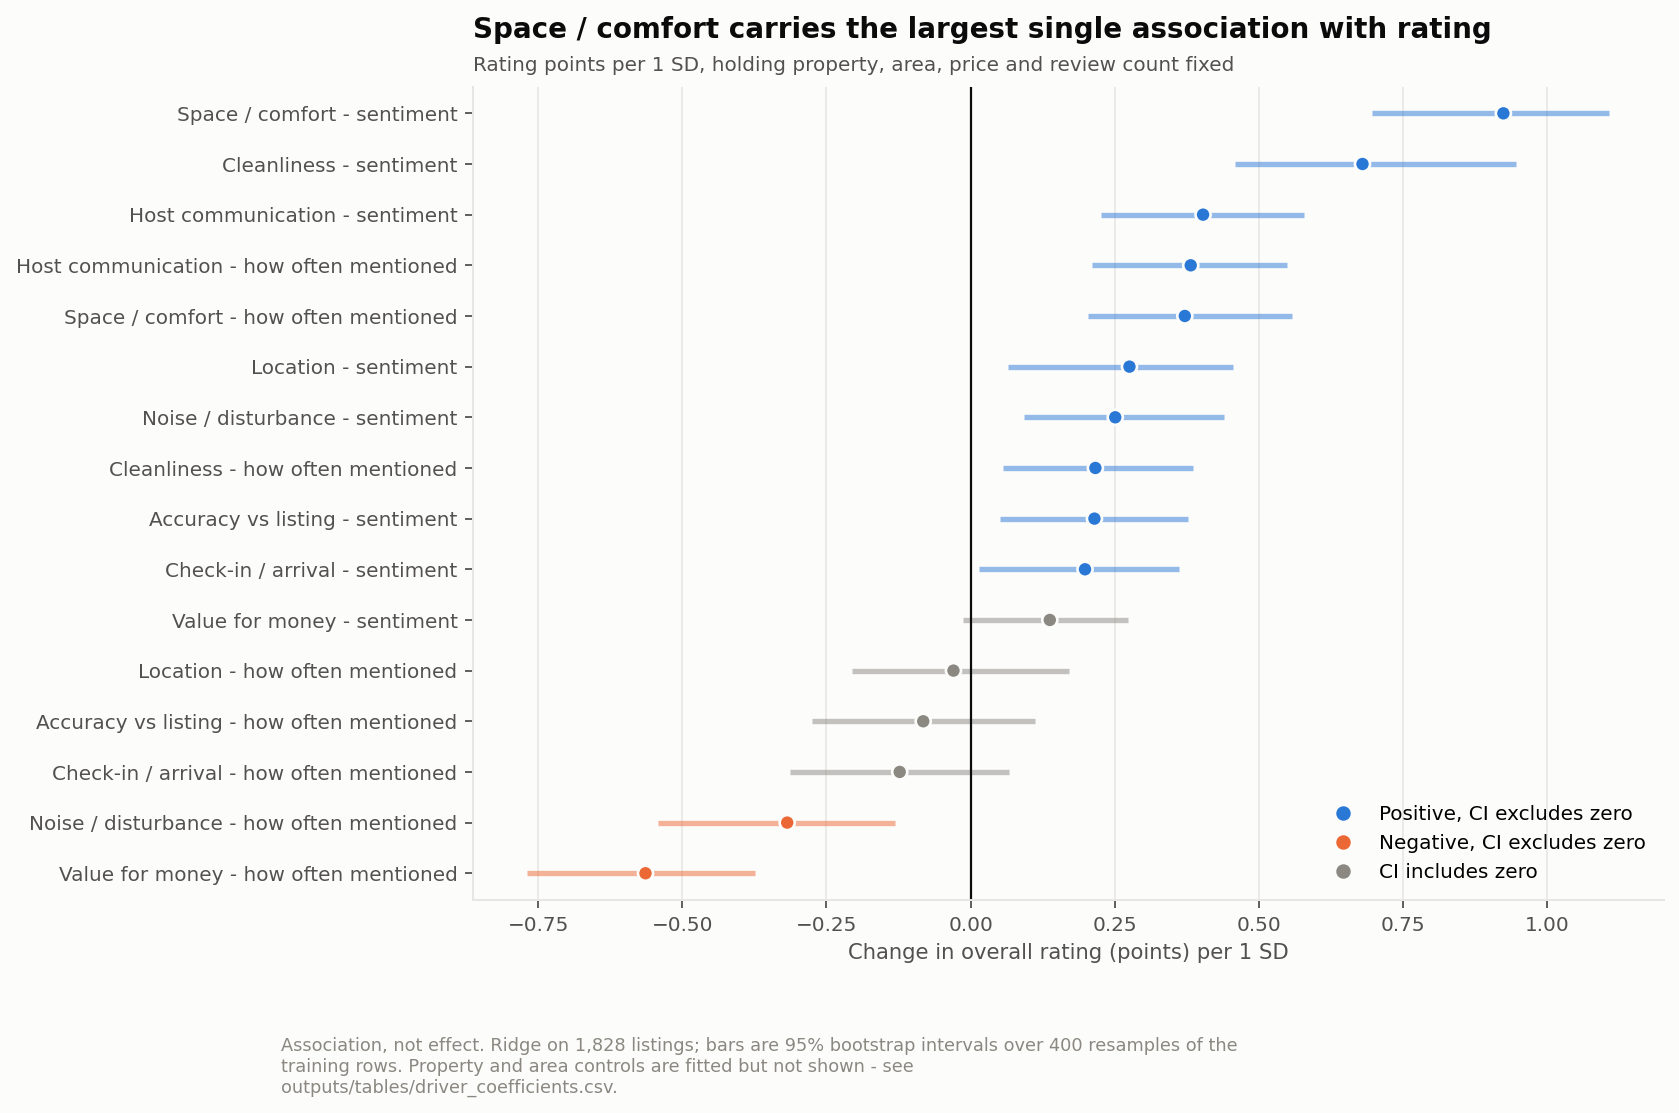

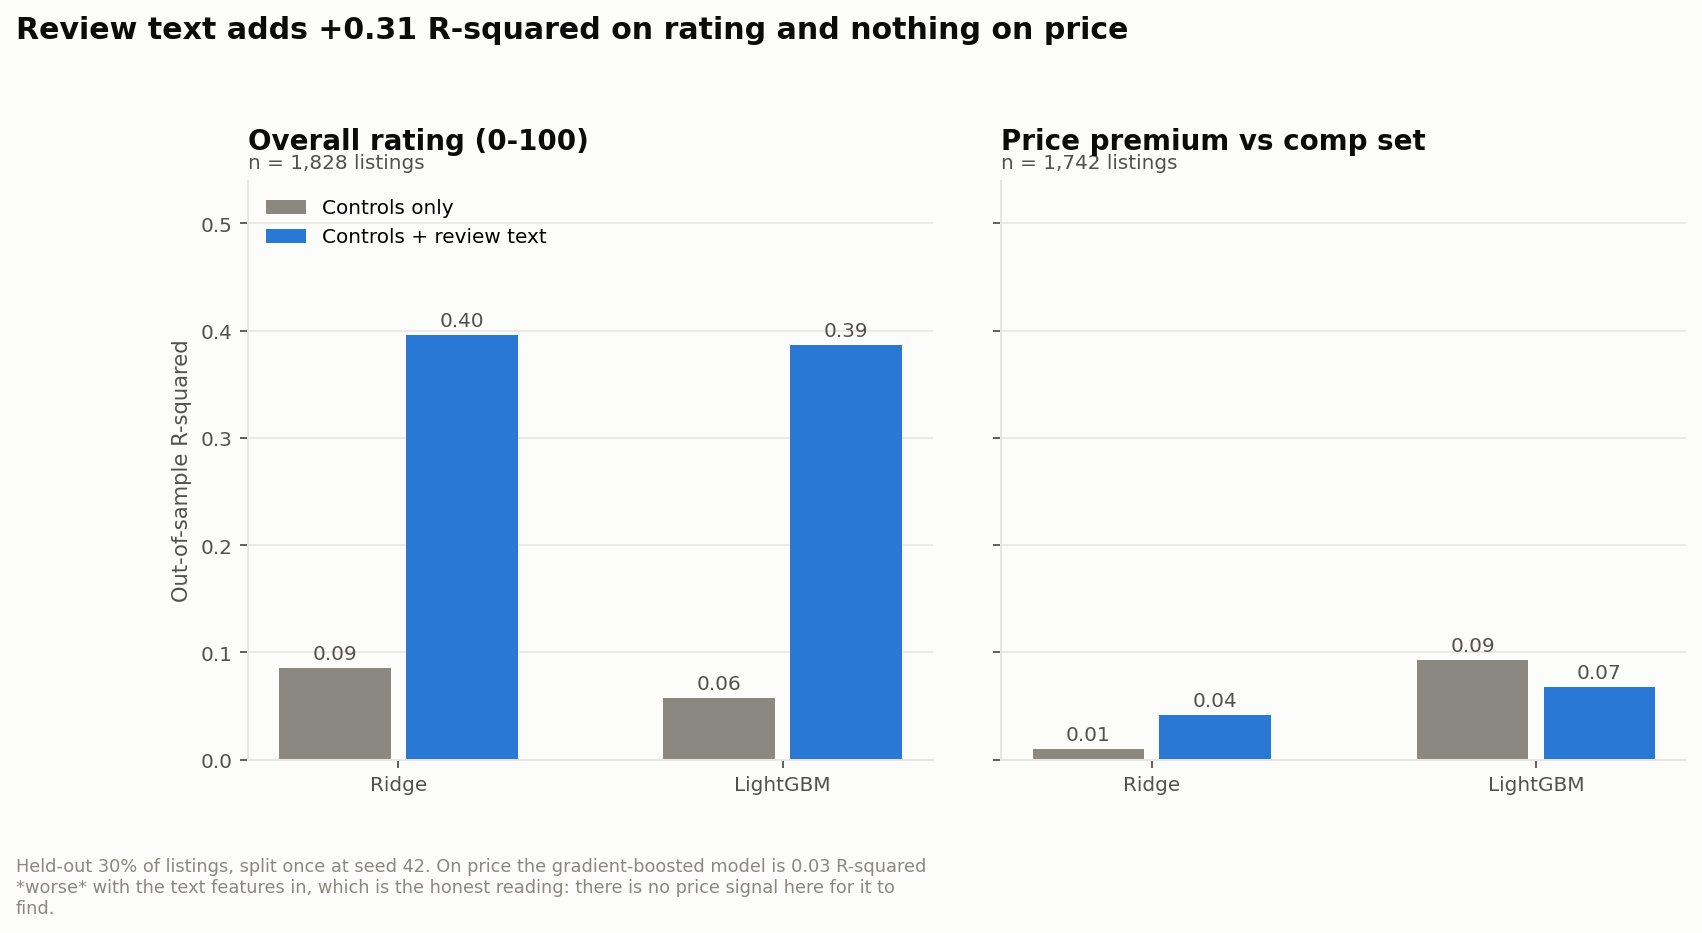

In [6]:
d = metrics("driver_metrics")
print("rating        - controls only:", round(d["rating"]["ridge_r2_controls_only"], 3),
      "| with aspects:", round(d["rating"]["ridge_r2_full"], 3))
print("price premium - controls only:", round(d["price_premium"]["ridge_r2_controls_only"], 3),
      "| with aspects:", round(d["price_premium"]["ridge_r2_full"], 3))
rc = pd.DataFrame(d["rating_coefficients"]).T
display(rc.sort_values("coef", key=abs, ascending=False).head(10).round(3))
show("06_rating_drivers.png")
show("07_model_comparison.png")

The same aspects explain almost nothing about price. Text moves the *rating* and barely touches what a listing can charge against its comparable set — which is the commercially important half of the answer.

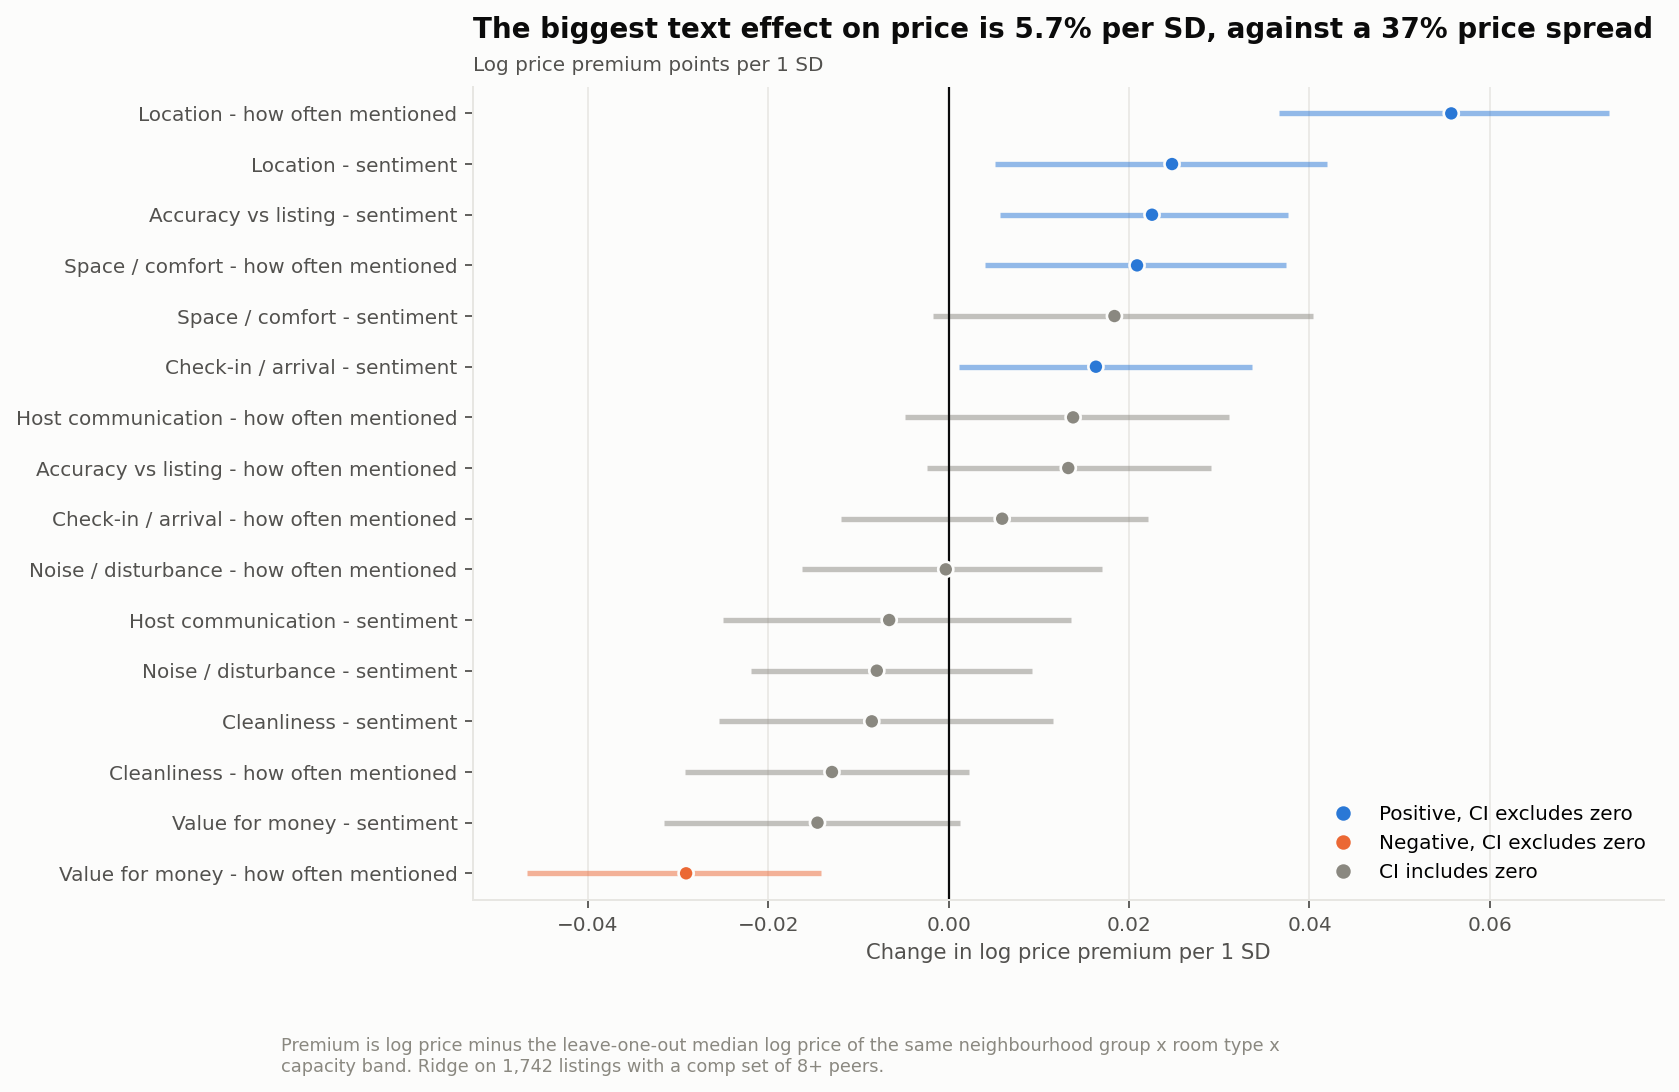

In [7]:
show("08_premium_drivers.png")

## 6. What complaint language actually looks like

Topic modelling run separately on high- and low-rated listings. The distinguishing terms are more useful than the topics: the lower band over-uses *problem, issues, noisy, loud, sleep*; the upper band *cottage, beautiful, wonderful, fresh, welcome*.

,term,z,n_lower,n_upper
0,cottage,-25.555363,241.0,1585.0
1,beautiful,-24.107701,1354.0,3309.0
2,home,-22.433986,3489.0,6282.0
3,wonderful,-21.868811,1849.0,3854.0
4,studio,-17.606018,574.0,1529.0
5,loved,-15.077042,1285.0,2431.0
6,lovely,-14.747622,1429.0,2611.0
7,amazing,-14.526614,1163.0,2214.0
8,fresh,-13.367521,286.0,808.0
9,welcome,-13.363037,735.0,1509.0


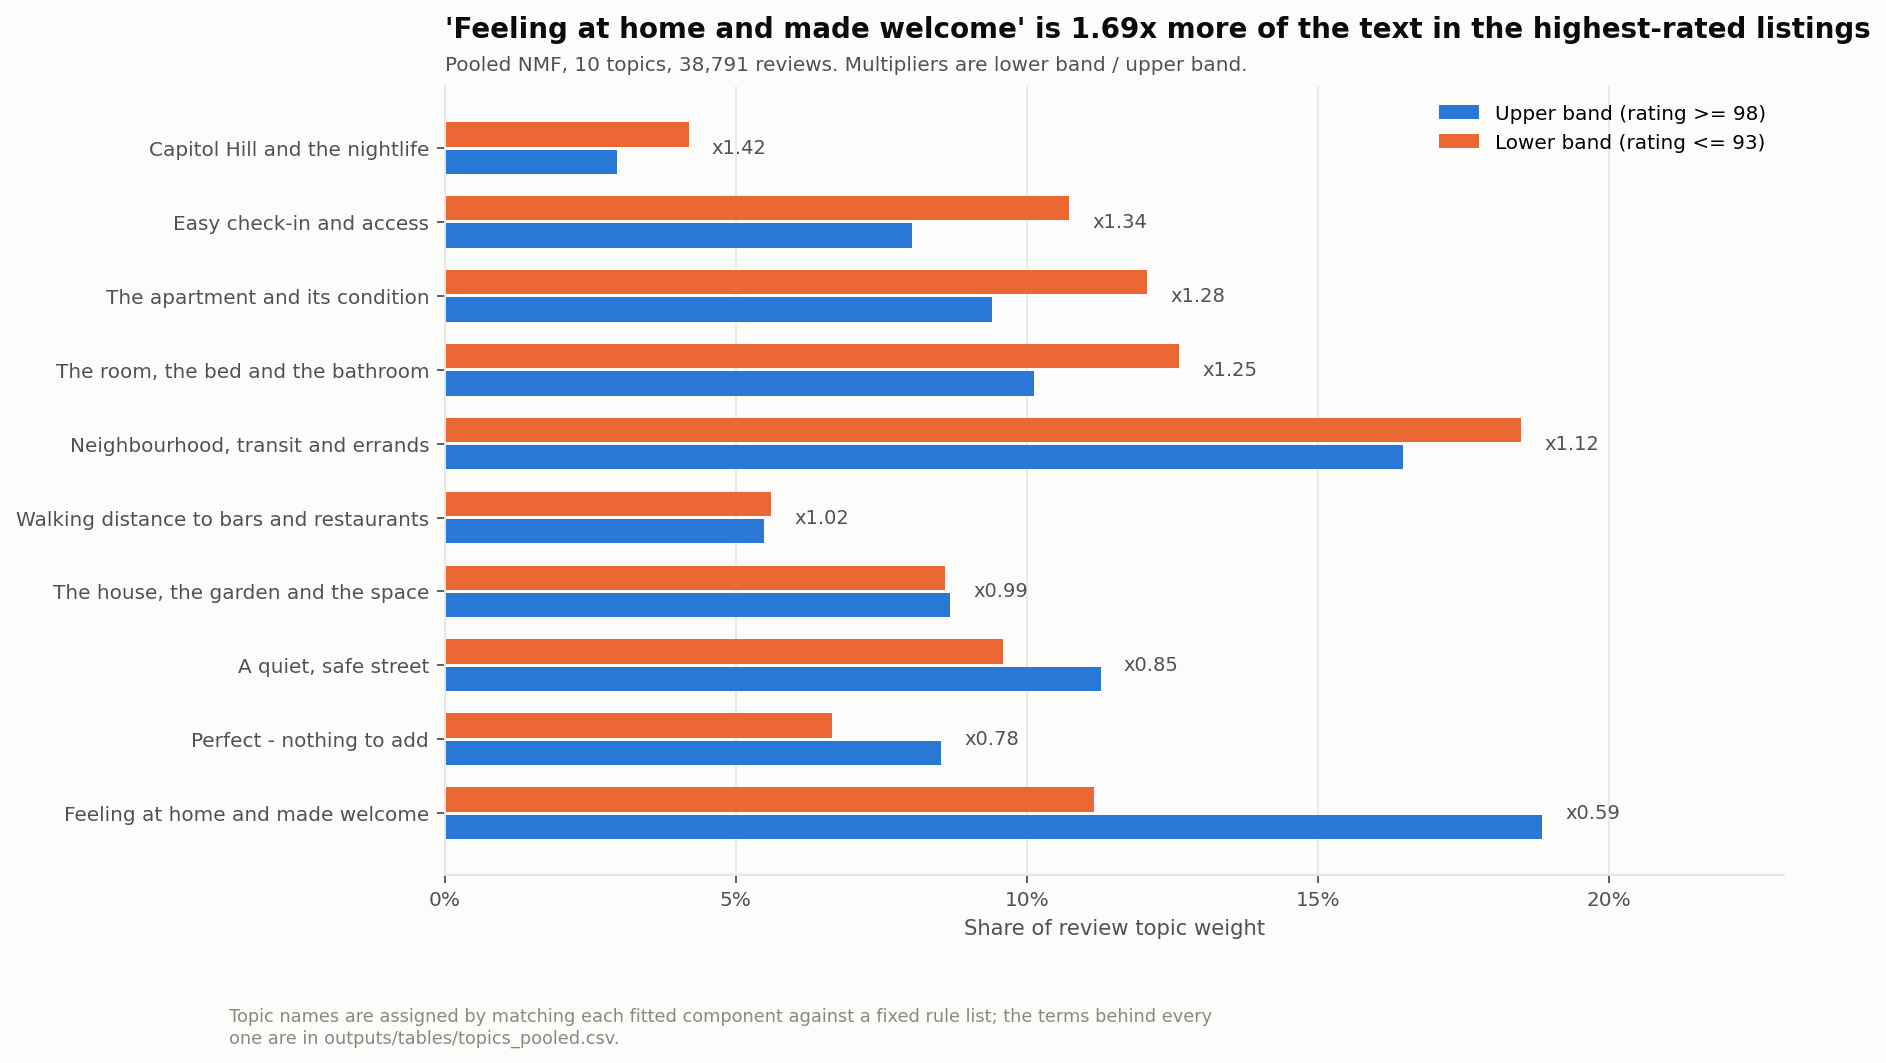

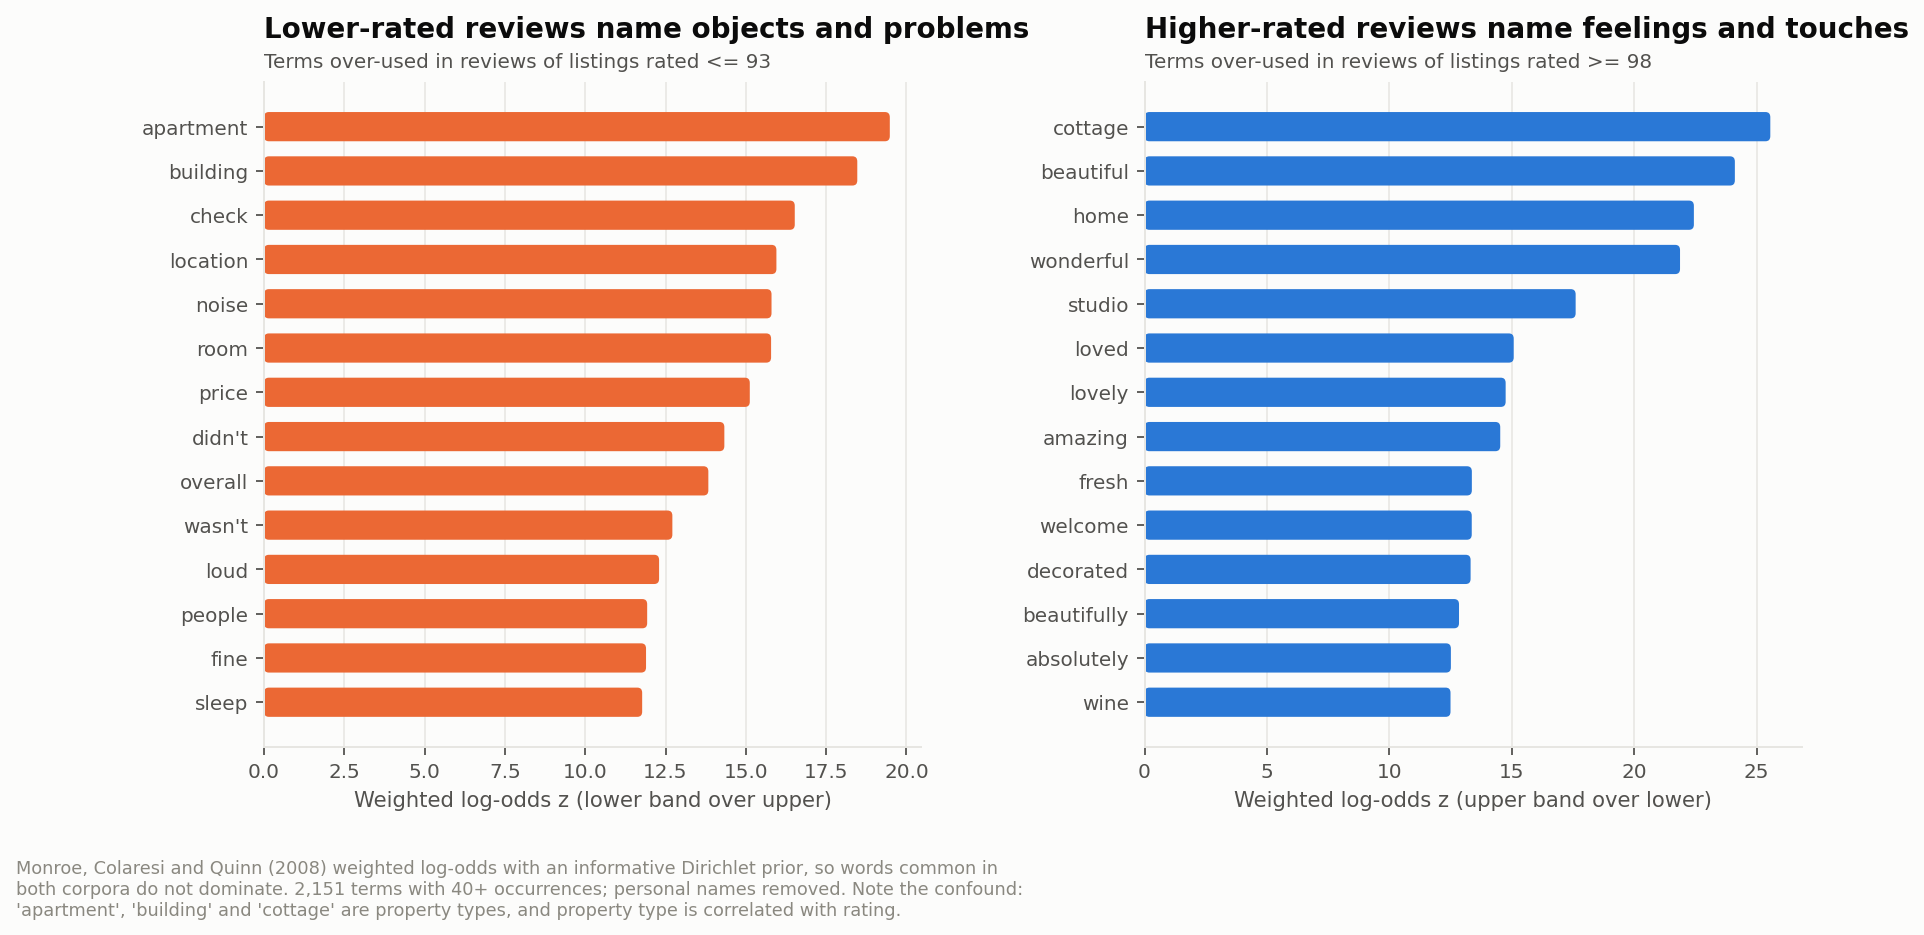

In [8]:
t = metrics("topic_metrics")
display(pd.read_csv(OUT / "tables" / "distinguishing_terms.csv").head(20))
show("09_topic_prevalence.png")
show("10_complaint_language.png")

## 7. The deliverable: where to spend first

Importance (effect on rating) against performance (complaint rate). Four quadrants, each implying a different action. The whole prize — moving a bottom-quartile listing to the portfolio median on every attribute — is 1.9 rating points, and space/comfort alone is 0.58 of it.

Read against section 2: 1.9 points on a scale where the mean is 94.5 and a quarter of listings already score 100.

fix first : ['Location', 'Space / comfort']
maintain  : ['Cleanliness', 'Host communication']
low prio  : ['Check-in / arrival', 'Noise / disturbance']
watch     : ['Value for money', 'Accuracy vs listing']
total prize: 1.89 rating points


,aspect,label,importance,importance_lo,importance_hi,evidence,complaint_rate,complaint_per_mention,mention_rate,mean_sentiment,listings_measured,gap_p25_to_median_sd,rating_points_available,imp_side,perf_side,quadrant,action
0,cleanliness,Cleanliness,0.680,0.459,0.945,clear,0.005,0.014,0.379,0.651,1791,0.518,0.352,high,high,Maintain,"Matters and is already working - protect it, d..."
1,location,Location,0.276,0.065,0.455,clear,0.016,0.020,0.785,0.510,1828,0.700,0.193,high,low,Fix first,"Matters, and currently goes wrong most often"
2,host_communication,Host communication,0.403,0.226,0.578,clear,0.008,0.013,0.622,0.586,1826,0.647,0.261,high,high,Maintain,"Matters and is already working - protect it, d..."
3,checkin,Check-in / arrival,0.198,0.015,0.362,clear,0.012,0.050,0.243,0.435,1690,0.605,0.120,low,low,Low priority,"Goes wrong, but moving it barely moves the rating"
4,value,Value for money,0.137,-0.013,0.273,inconclusive,0.005,0.069,0.074,0.467,1013,0.621,0.085,low,high,Possible over-investment,Evidence inconclusive: the importance interval...
5,accuracy,Accuracy vs listing,0.215,0.050,0.377,clear,0.006,0.035,0.179,0.380,1600,0.594,0.128,low,high,Possible over-investment,"Already excellent, and improving it further bu..."
6,noise,Noise / disturbance,0.251,0.093,0.440,clear,0.015,0.062,0.242,0.451,1684,0.712,0.179,low,low,Low priority,"Goes wrong, but moving it barely moves the rating"
7,space_comfort,Space / comfort,0.924,0.696,1.108,clear,0.013,0.020,0.682,0.558,1828,0.624,0.577,high,low,Fix first,"Matters, and currently goes wrong most often"


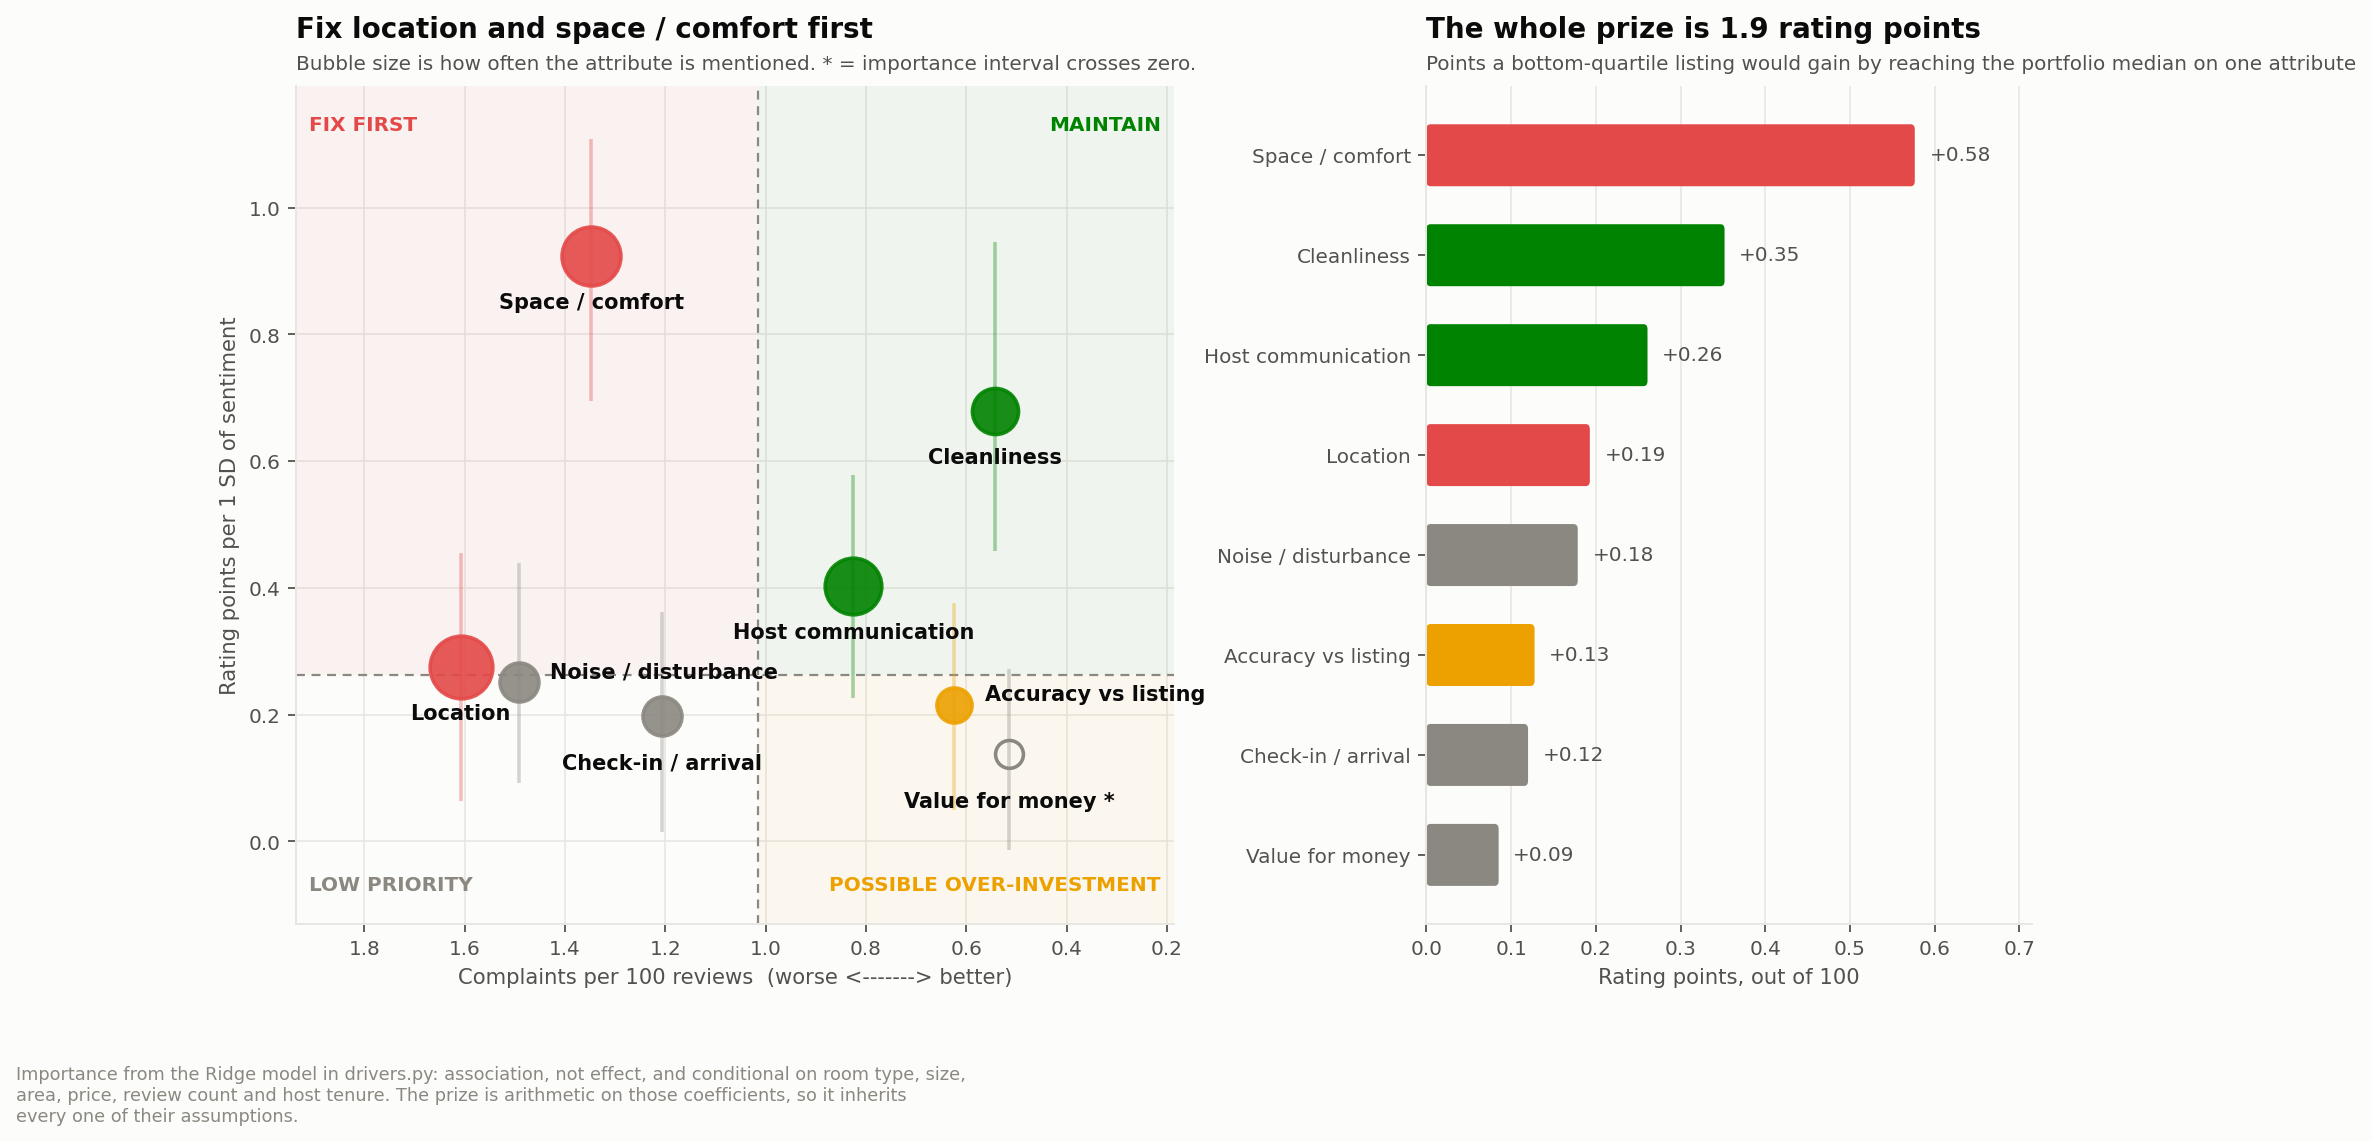

In [9]:
p = metrics("priority_metrics")
print("fix first :", p["fix_first"])
print("maintain  :", p["maintain"])
print("low prio  :", p["low_priority"])
print("watch     :", p["over_investment"])
print("total prize:", round(p["total_rating_points_available"], 2), "rating points")
display(pd.read_csv(OUT / "tables" / "priority_actions.csv").round(3))
show("11_priority_matrix.png")

## 8. Where in the city

Neighbourhood-level read at the `neighbourhood_group` level, with a minimum listing count enforced — small-n neighbourhoods produce differences that are noise. Only a minority of cells clear two standard errors, and that is stated rather than smoothed over.

,neighbourhood_group_cleansed,listings,median_price,mean_rating,mean_price_premium,reviews,z_Cleanliness,z_Location,z_Host communication,z_Check-in / arrival,z_Value for money,z_Accuracy vs listing,z_Noise / disturbance,z_Space / comfort
0,Ballard,125,92.0,95.424,0.014,6706,0.144,0.208,0.029,-0.011,0.101,0.083,0.167,0.237
1,Beacon Hill,70,75.0,94.329,-0.065,3111,-0.034,-0.721,-0.164,-0.073,0.118,-0.097,-0.162,-0.125
2,Capitol Hill,251,110.0,94.578,0.024,11265,-0.104,0.357,0.010,0.064,-0.104,-0.022,0.010,0.013
3,Cascade,29,115.0,94.586,0.038,1239,0.067,0.315,-0.072,0.023,-0.448,0.263,-0.133,0.232
4,Central Area,187,90.0,95.273,-0.018,7757,-0.051,-0.073,0.154,0.062,0.131,0.077,0.169,0.093
5,Delridge,40,69.5,95.900,-0.073,2051,0.222,-0.766,0.160,0.159,0.226,-0.219,0.039,0.112
6,Downtown,271,135.0,94.432,-0.026,11628,-0.093,-0.023,-0.382,-0.190,-0.392,-0.131,-0.720,-0.360
7,Lake City,28,66.5,94.643,-0.038,894,-0.288,-0.500,0.143,-0.536,-0.024,-0.436,0.206,0.001
8,Magnolia,26,104.5,94.154,-0.023,838,0.030,-0.147,0.130,0.053,-0.237,-0.285,0.313,-0.355
9,Northgate,37,80.0,95.865,0.039,1268,0.061,-0.403,0.270,0.166,-0.037,-0.216,0.374,0.044


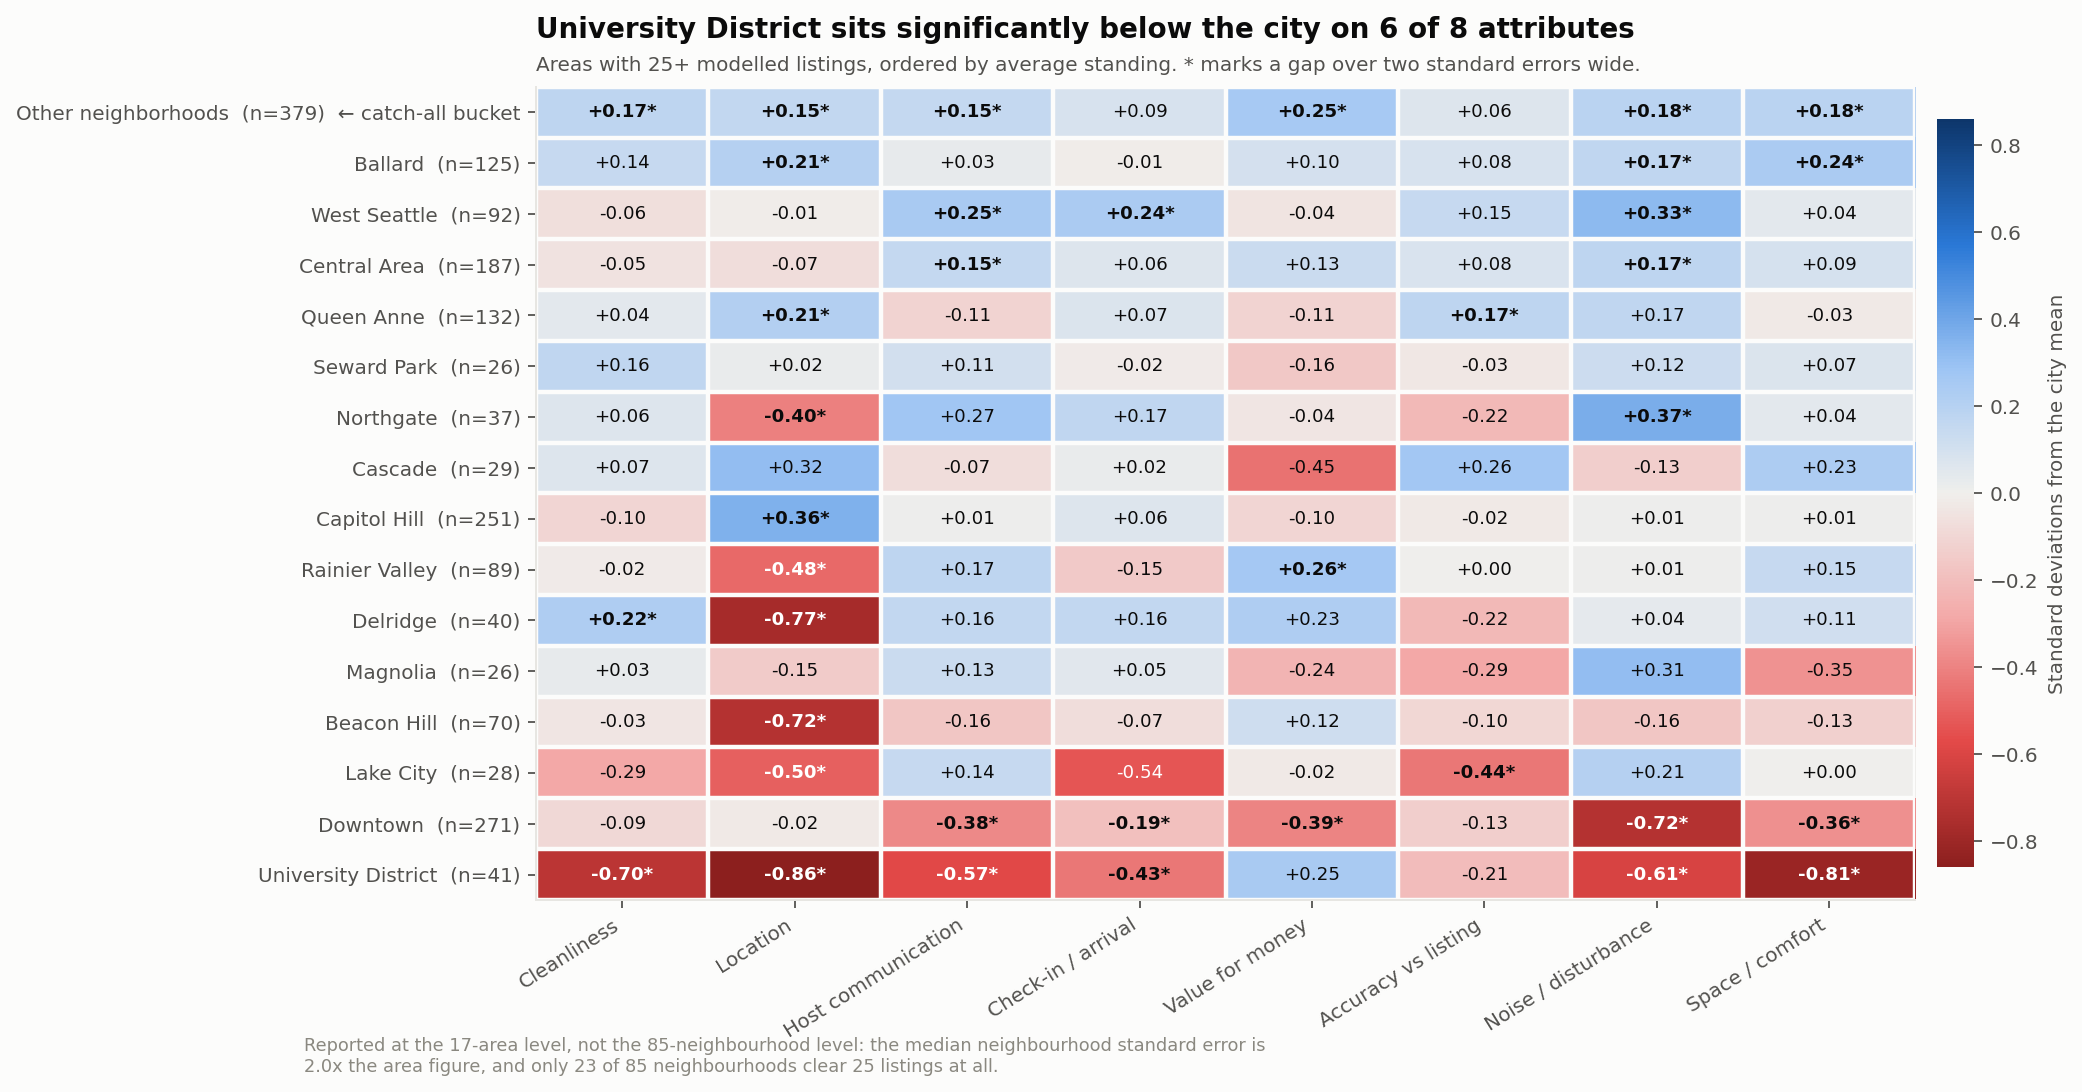

In [10]:
display(pd.read_csv(OUT / "tables" / "neighbourhood_profile.csv").round(3).head(15))
show("12_neighbourhood_positioning.png")

## What this cannot tell you

- **The ratings are compressed.** Mean 94.5, a quarter at exactly 100. Effect sizes are small because the outcome barely varies, and reviewers are self-selected — unhappy guests mostly do not review.
- **No causality.** The host-quality confound above is not resolvable with this data.
- **Validation is weak** (mean r = 0.27) and the largest single effect has no subscore to check it against.
- **English only**, one heuristic screen, 2016 Seattle.

See `docs/method.md` for the full version.